In [5]:
import numpy as np
import scipy.sparse as sp
import scipy.sparse.linalg as sla
import matplotlib.pyplot as plt

In [4]:
def rectangle_mask(Lx, Ly, h):
    # interior points only; the wall sits one grid step outside the True region
    nx, ny = int(round(Lx / h)) - 1, int(round(Ly / h)) - 1
    return np.ones((nx, ny), dtype=bool)


def quarter_stadium_mask(a, r, h):
    # x >= 0, y >= 0; the walls at x = 0 and y = 0 are the symmetry axes (Dirichlet)
    x = h * np.arange(1, int(round((a + r) / h)))
    y = h * np.arange(1, int(round(r / h)))
    X, Y = np.meshgrid(x, y, indexing='ij')
    dx = np.maximum(X - a, 0)
    return dx**2 + Y**2 < r**2


def laplacian(mask, h):
    # -Laplacian (5-point) on the True points; neighbors outside the mask are psi = 0
    idx = -np.ones(mask.shape, dtype=int)
    idx[mask] = np.arange(mask.sum())
    rows, cols = [], []
    for sx, sy in [(1, 0), (-1, 0), (0, 1), (0, -1)]:
        nb = np.full(mask.shape, -1)
        xs = slice(max(-sx, 0), mask.shape[0] - max(sx, 0))
        ys = slice(max(-sy, 0), mask.shape[1] - max(sy, 0))
        xd = slice(max(sx, 0), mask.shape[0] + min(sx, 0))
        yd = slice(max(sy, 0), mask.shape[1] + min(sy, 0))
        nb[xs, ys] = idx[xd, yd]
        ok = mask & (nb >= 0)
        rows.append(idx[ok])
        cols.append(nb[ok])
    rows, cols = np.concatenate(rows), np.concatenate(cols)
    M = mask.sum()
    off = sp.coo_matrix((-np.ones(len(rows)), (rows, cols)), shape=(M, M))
    return (4 * sp.identity(M) + off).tocsc() / h**2


def solve(mask, h, k):
    E, V = sla.eigsh(laplacian(mask, h), k=k, sigma=0, which='LM')
    order = np.argsort(E)
    E, V = E[order], V[:, order]
    psi = np.zeros(mask.shape + (k,))
    psi[mask] = V / h  # normalized so sum |psi|^2 h^2 = 1
    return E, psi


def ipr(psi, h):
    return (psi**4).sum(axis=(0, 1)) * h**2


def plot_states(mask, psi, E, I, which, ncols=4):
    nrows = int(np.ceil(len(which) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(3.2 * ncols, 2.4 * nrows), squeeze=False)
    for ax in axes.ravel():
        ax.axis('off')
    for ax, i in zip(axes.ravel(), which):
        dens = np.ma.masked_where(~mask, psi[..., i] ** 2).T
        ax.imshow(dens, origin='lower', cmap='magma')
        ax.set_title(f'#{i}  E={E[i]:.1f}  IPR={I[i]:.2f}', fontsize=9)
    fig.tight_layout()
    plt.show()

In [6]:
# sanity check: rectangle with irrational aspect ratio vs E = pi^2 (n^2/Lx^2 + m^2/Ly^2)
Lx, Ly, h = np.pi, np.pi * (np.sqrt(5) - 1) / 2, 0.02
E_rect, _ = solve(rectangle_mask(Lx, Ly, h), h, 10)
exact = sorted(np.pi**2 * (n**2 / Lx**2 + m**2 / Ly**2) for n in range(1, 8) for m in range(1, 8))[:10]
print(np.round(E_rect, 3))
print(np.round(exact, 3))

[ 3.623  6.626 11.487 11.629 14.489 18.63  19.492 24.584 26.494 27.586]
[ 3.618  6.618 11.472 11.618 14.472 18.618 19.472 24.562 26.472 27.562]


In [7]:
# quarter stadium, 300 lowest states
a, r, h = 1.0, 1.0, 0.02
mask = quarter_stadium_mask(a, r, h)
E, psi = solve(mask, h, 300)
I = ipr(psi, h)
print(mask.shape, int(mask.sum()), 'grid points')

(99, 49) 4357 grid points


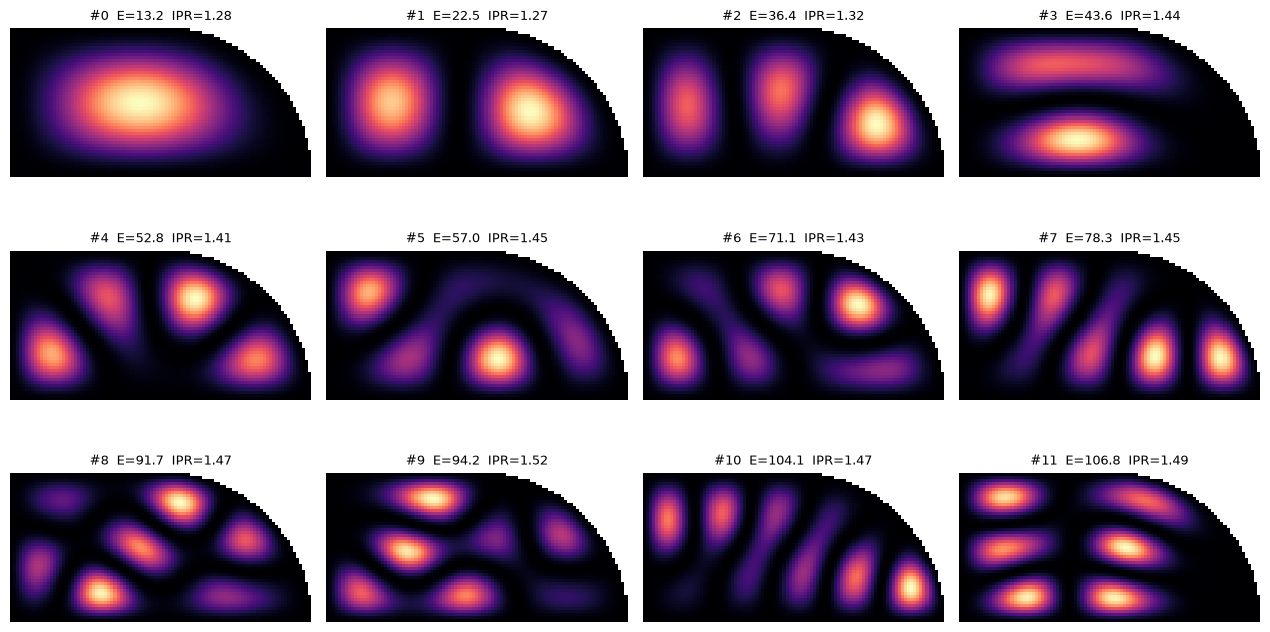

In [8]:
# the 12 lowest eigenstates, |psi|^2
plot_states(mask, psi, E, I, range(12))

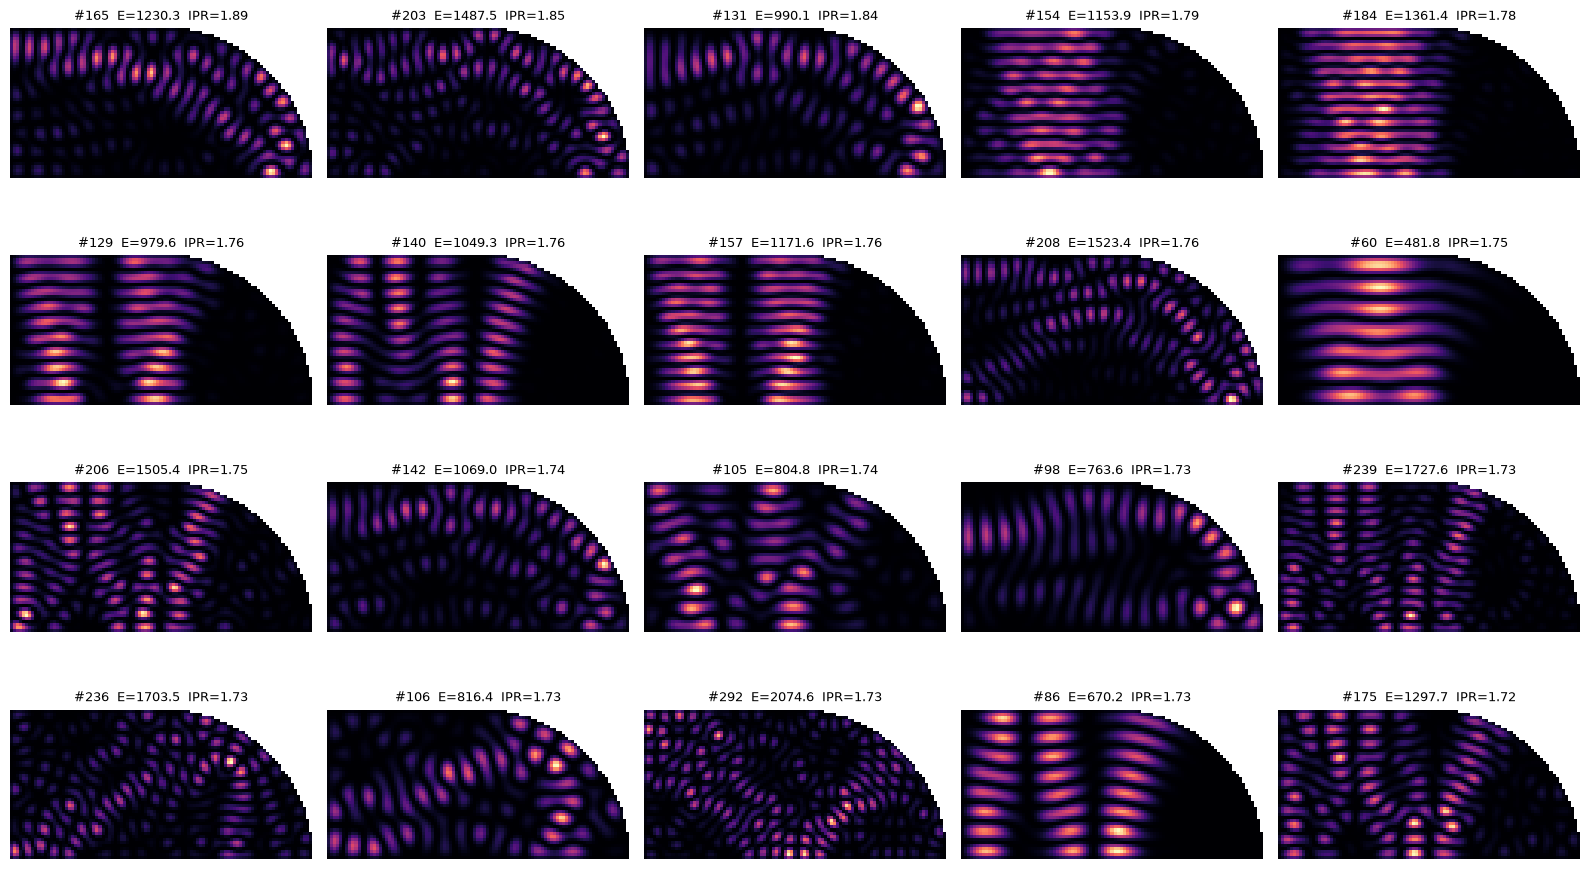

In [9]:
# the 20 most localized states by inverse participation ratio
top = np.argsort(I)[::-1][:20]
plot_states(mask, psi, E, I, top, ncols=5)

## Spectral statistics

Plan: unfold the eigenvalues, then compare the gap statistics of the rectangle (Poisson) against the quarter stadium (Wigner / GOE).

### 1. Unfold the spectrum

Goal: map each level E_i to eps_i = N(E_i) so the mean spacing is 1.

- [ ] Choose a smooth N(E): Weyl's law (needs area and perimeter) or a polynomial fit to the staircase
- [ ] Decide how many low levels to drop
- [ ] Check that the mean spacing is about 1

In [12]:
def unfold(E):
    # return the unfolded levels eps
    A = np.pi * r**2 / 4 + a*r
    P = np.pi/2 + 2*a + 2*r
    def N(E):
        return (A / (4 * np.pi))*E - (P/(np.pi * 4)) * np.sqrt(E)

    eps = N(E)          # same length as E, one ε per level
    s = np.diff(eps)    # nearest-neighbor spacings, mean ≈ 1


### 2. Nearest-neighbor spacing distribution P(s)

- [ ] Compute spacings s_i from the unfolded levels
- [ ] Histogram them (normalized) and overlay the Poisson and Wigner curves
- [ ] Do the same for the rectangle, using a few hundred levels
- [ ] Optional: plot the cumulative distribution instead, which is less noisy

TypeError: 'NoneType' object is not subscriptable

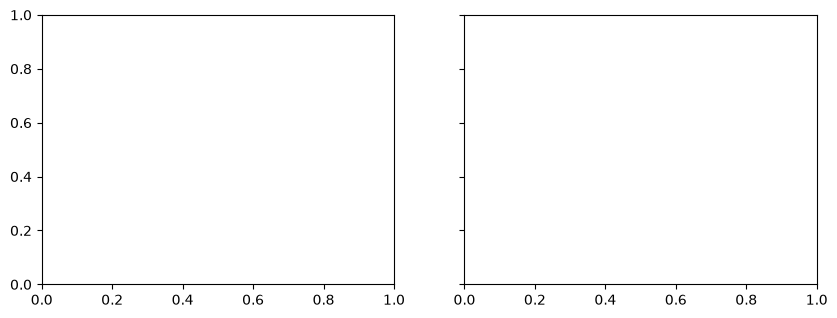

In [13]:
# rectangle with a few hundred levels (same irrational aspect ratio as before)
Lx, Ly, h_rect = np.pi, np.pi * (np.sqrt(5) - 1) / 2, 0.02
E_rect, _ = solve(rectangle_mask(Lx, Ly, h_rect), h_rect, 300)

drop = 20  # low levels where Weyl's law is poor


def spacings(E):
    return np.diff(unfold(E)[drop:])


def poisson(s):
    return np.exp(-s)


def wigner(s):
    return (np.pi * s / 2) * np.exp(-np.pi * s**2 / 4)


s_grid = np.linspace(0, 4, 400)
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5), sharey=True)
for ax, levels, name in [(axes[0], E_rect, 'rectangle'), (axes[1], E, 'quarter stadium')]:
    s = spacings(levels)
    ax.hist(s, bins=20, range=(0, 4), density=True, alpha=0.6, label=f'{name} (mean s = {s.mean():.2f})')
    ax.plot(s_grid, poisson(s_grid), 'k--', label='Poisson')
    ax.plot(s_grid, wigner(s_grid), 'r-', label='Wigner (GOE)')
    ax.set_xlabel('s')
    ax.legend()
axes[0].set_ylabel('P(s)')
fig.tight_layout()
plt.show()

### 3. Mean gap ratio <r>

No unfolding needed, so it is a cross-check on step 1. Reference values: Poisson ~ 0.386, GOE ~ 0.536.

- [ ] Compute <r> for the rectangle and the quarter stadium

In [ ]:
# TODO

### 4. Checks and extensions

- [ ] Grid convergence: do the levels shift when h is halved?
- [ ] Full stadium vs quarter stadium: does the full one look wrong?
- [ ] Disc, Sinai billiard, L-shape
- [ ] Optional: spectral rigidity or number variance
- [ ] Scars: are the top-IPR states bouncing-ball modes or true scars?

In [ ]:
# TODO